[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/xai_decathlon.ipynb)

# XAI Decathlon: Round 1 Individual Method Trial

In this lab, each student works with **one assigned explainability method** and tries to use it across ten explanation events.

The notebook gives you:

- Two trained target models: one tabular model and one image model.
- Ten event prompts with ready-to-use model objects, data objects, and assigned cases.
- A markdown results table to fill in as you go.
- A final model-profile prompt for summarizing what your method can and cannot support.

The notebook does **not** implement LIME, SHAP, PDP, ALE, Grad-CAM, Score-CAM, saliency, counterfactuals, or any other explanation method for you. That is the challenge.

**Estimated time:** 60-75 minutes  
**Format:** individual method trial  
**Deliverable:** a completed results table plus a short model profile


## Core Lesson

Different explanation methods answer different kinds of questions.

Your job is to find out where your assigned method is useful, where it is only partially useful, and where it simply does not fit the task. A method can earn a strong score for saying something clear and justified, including: "this method cannot answer this event question."

This notebook is intentionally only the individual round. Later, you may compare results with classmates who used different methods.


## Scoring Rules

For each event, assign your method one medal:

- **Gold:** directly answers the event question with convincing evidence.
- **Silver:** gives useful partial evidence, but another method or assumption is needed.
- **Bronze:** gives weak, indirect, or fragile evidence.
- **DNF:** does not finish: the method is mismatched, misleading, or not usable for the event.

A pretty visualization is not automatically a medal. Score the method based on whether it answers the event question.


## The Ten Events

| Event | Question |
|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? |
| 5. Compare Two Predictions | Why were two cases classified differently? |
| 6. Feature Interactions | Which tabular variables work together? |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? |
| 8. Explain a Failure | Why did the model make this mistake? |
| 9. Estimate Trustworthiness | Should a human trust this prediction? |
| 10. Reverse Engineer Strategy | What strategy has each model learned? |

## Results Table

Edit this markdown cell as you work through the events. Keep each evidence claim short enough that someone else can understand what your method showed and why you assigned the medal.

**My assigned method:** Counterfactual explanations

| Event | Question | Medal | Evidence from my method | Limitations or notes |
|---|---|---|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? | TODO |  |  |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? | Silver | For local row 718, changing only `debt_ratio` from 0.281 to 0.283 changed the model from low risk (`P=0.499`) to high risk (`P=0.502`). | The case is extremely close to the decision boundary. Counterfactuals show model sensitivity, not causality. |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? | TODO |  |  |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? | Gold | Sweeping `debt_ratio` from 0.075 to 0.590 increased average `P(high risk)` from 0.148 to 0.442 and increased the high-risk prediction rate from 0.8% to 25.2%. | This is a model-behavior sweep, not a causal estimate; other correlated features were held fixed. |
| 5. Compare Two Predictions | Why were two cases classified differently? | Gold | The high-risk case had `P=0.789` versus `0.022` for the low-risk case. Replacing one feature at a time showed that `debt_ratio` (`+0.147`) and `recent_late_payments` (`+0.103`) contributed the largest probability increases. | One-feature interventions isolate effects but do not capture feature interactions or prove causality. |
| 6. Feature Interactions | Which tabular variables work together? | TODO |  |  |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? | TODO |  |  |
| 8. Explain a Failure | Why did the model make this mistake? | Silver | Failure row 1 is truly high risk but predicted low risk with `P=0.400`. Changing only `recent_late_payments` from 1 to 2 flips the model to high risk, revealing a likely missed signal. | Counterfactuals explain what would change the model's output, not why the real label was high risk. |
| 9. Estimate Trustworthiness | Should a human trust this prediction? | TODO |  |  |
| 10. Reverse Engineer Strategy | What strategy has each model learned? | TODO |  |  |


In [2]:
#@title Setup
# Run this cell first. It imports only the libraries needed to create the target models.
# You may add your own XAI imports later in the "Your method implementation" section.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [ ]:
#@title Event guide helper
# This table points you to the model/data objects for each event.

EVENTS = [
    "1. Most important feature",
    "2. One specific prediction",
    "3. Dataset bias or shortcut",
    "4. Global feature effect",
    "5. Compare two predictions",
    "6. Feature interactions",
    "7. Where is the model looking?",
    "8. Explain a failure",
    "9. Estimate trustworthiness",
    "10. Reverse engineer strategy",
]

event_guide = pd.DataFrame({
    "event": EVENTS,
    "target": [
        "Tabular risk model",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular risk model",
        "Tabular or image cases",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular or image failure case",
        "Either target model",
        "Both target models",
    ],
    "primary_objects": [
        "risk_model, X_train, X_test, feature_names, predict_risk_proba",
        "tabular_local_case, X_test, predict_risk_proba",
        "image_shortcut_case, image_reference_case, test_imgs, predict_image_proba",
        "X_train, X_test, feature_names, predict_risk_proba",
        "tabular_low_case vs tabular_high_case, or assigned_image_cases",
        "X_train, X_test, feature_names, predict_risk_proba",
        "image_model, test_imgs, assigned_image_cases, show_image_case",
        "tabular_failure_case or image_failure_case",
        "assigned cases, predicted probabilities, explanation stability checks",
        "all model interfaces and prior event evidence",
    ],
    "question_type": [
        "global feature importance",
        "local prediction explanation",
        "shortcut or bias diagnosis",
        "global feature effect",
        "contrastive explanation",
        "interaction discovery",
        "spatial localization",
        "failure diagnosis",
        "trust and uncertainty judgment",
        "synthesis and model profiling",
    ],
})

event_guide


# Target Model 1: Tabular Risk Model

You are given a trained model that predicts whether a synthetic applicant is **high risk**.

The model sees these features:

- `age`
- `income_k`
- `debt_ratio`
- `loyalty_years`
- `recent_late_payments`
- `savings_k`
- `app_minutes`
- `support_tickets`
- `zip_proxy`
- `promo_seen`

Treat this as a model you need to investigate. Some variables are directly meaningful, some are weak, some may act like shortcuts, and some may interact.

In [3]:
#@title Create the tabular data and train the risk model

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_tabular_data(n=3000, seed=SEED):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 76, size=n)
    income_k = np.clip(rng.normal(72, 24, size=n), 18, 180)
    debt_ratio = np.clip(rng.beta(2.2, 5.0, size=n), 0.01, 0.98)
    loyalty_years = np.clip((age - 18) * rng.beta(1.5, 6.0, size=n), 0, 35)
    recent_late_payments = rng.poisson(0.65 + 1.8 * debt_ratio, size=n)
    savings_k = np.clip(rng.lognormal(mean=2.35, sigma=0.8, size=n), 0, 120)
    app_minutes = np.clip(rng.normal(18, 7, size=n), 2, 60)
    support_tickets = rng.poisson(0.3 + 0.5 * (debt_ratio > 0.45), size=n)

    zip_proxy = rng.binomial(1, sigmoid(-0.9 + 1.9 * debt_ratio - 0.012 * income_k), size=n)
    promo_seen = rng.binomial(1, sigmoid(-0.3 + 1.4 * zip_proxy + 0.8 * (age < 30)), size=n)
    young_high_debt = ((age < 30) & (debt_ratio > 0.48)).astype(float)

    logit = (
        -1.9
        + 3.8 * debt_ratio
        + 0.38 * recent_late_payments
        - 0.018 * income_k
        - 0.024 * savings_k
        - 0.045 * loyalty_years
        + 0.85 * zip_proxy
        + 0.55 * promo_seen
        + 1.25 * young_high_debt
        + 0.025 * support_tickets
        + rng.normal(0, 0.45, size=n)
    )
    p = sigmoid(logit)
    y = rng.binomial(1, p)

    X = pd.DataFrame({
        "age": age,
        "income_k": income_k,
        "debt_ratio": debt_ratio,
        "loyalty_years": loyalty_years,
        "recent_late_payments": recent_late_payments,
        "savings_k": savings_k,
        "app_minutes": app_minutes,
        "support_tickets": support_tickets,
        "zip_proxy": zip_proxy,
        "promo_seen": promo_seen,
    })
    return X, pd.Series(y, name="high_risk")

X, y = make_tabular_data()
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=7,
    min_samples_leaf=12,
    random_state=SEED,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

tabular_pred = risk_model.predict(X_test)
tabular_proba = risk_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, tabular_pred), 3))
print("Positive class rate in test set:", round(float(y_test.mean()), 3))
print(classification_report(y_test, tabular_pred, target_names=["low risk", "high risk"]))
X_train.head()

Accuracy: 0.805
Positive class rate in test set: 0.224
              precision    recall  f1-score   support

    low risk       0.81      0.97      0.89       582
   high risk       0.70      0.23      0.34       168

    accuracy                           0.81       750
   macro avg       0.76      0.60      0.61       750
weighted avg       0.79      0.81      0.76       750



,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1583,42,60.186070,0.178157,3.750431,2,12.938567,8.853330,1,0,1
1035,61,125.055381,0.136064,3.955724,0,7.920787,8.808620,0,0,1
657,54,74.580820,0.488986,16.918809,1,2.733885,18.188498,0,0,0
968,71,71.595919,0.282121,7.306052,0,2.729296,19.732005,1,0,1
2298,30,81.528758,0.200992,0.374701,2,4.948344,13.871067,0,1,1


In [9]:
#@title Tabular model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_risk_proba(data):
    """Return [P(low risk), P(high risk)] for rows with the tabular feature columns."""
    if isinstance(data, pd.DataFrame):
        df = data[feature_names]
    else:
        df = pd.DataFrame(data, columns=feature_names)
    return risk_model.predict_proba(df)

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

# Cases for local, comparison, and failure events.
tabular_low_case = int(np.argmin(tabular_proba))
tabular_high_case = int(np.argmax(tabular_proba))
near_boundary_rows = np.argsort(np.abs(tabular_proba - 0.5))
tabular_local_case = first_distinct(near_boundary_rows, used={tabular_low_case, tabular_high_case})
wrong_rows = np.where(tabular_pred != y_test.to_numpy())[0]
tabular_failure_case = first_distinct(
    wrong_rows,
    used={tabular_local_case, tabular_low_case, tabular_high_case},
    fallback=tabular_local_case,
)

assigned_tabular_cases = pd.DataFrame({
    "case_name": ["local_case", "low_case", "high_case", "failure_case"],
    "row_index_in_X_test": [tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case],
    "true_label": [
        int(y_test.iloc[tabular_local_case]),
        int(y_test.iloc[tabular_low_case]),
        int(y_test.iloc[tabular_high_case]),
        int(y_test.iloc[tabular_failure_case]),
    ],
    "predicted_label": [
        int(tabular_pred[tabular_local_case]),
        int(tabular_pred[tabular_low_case]),
        int(tabular_pred[tabular_high_case]),
        int(tabular_pred[tabular_failure_case]),
    ],
    "predicted_P_high_risk": [
        round(float(tabular_proba[tabular_local_case]), 3),
        round(float(tabular_proba[tabular_low_case]), 3),
        round(float(tabular_proba[tabular_high_case]), 3),
        round(float(tabular_proba[tabular_failure_case]), 3),
    ],
})

assigned_tabular_cases

,case_name,row_index_in_X_test,true_label,predicted_label,predicted_P_high_risk
0,local_case,718,0,0,0.499
1,low_case,565,0,0,0.022
2,high_case,564,1,1,0.789
3,failure_case,1,1,0,0.400


# Target Model 2: Image Shortcut Model

You are given a tiny image classifier trained on synthetic images.

- Class `0`: circle
- Class `1`: square

The training data may contain a shortcut. The test set is designed so you can investigate whether the model learned the intended shape concept, a shortcut, or both.

In [4]:
#@title Create the image data and train the image model

def draw_shape_image(label, marker=None, seed=None, image_size=64):
    rng = np.random.default_rng(seed)
    img = np.ones((image_size, image_size, 3), dtype=np.float32) * 0.92
    img += rng.normal(0, 0.025, size=img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    yy, xx = np.mgrid[:image_size, :image_size]
    cx = image_size // 2 + int(rng.integers(-5, 6))
    cy = image_size // 2 + int(rng.integers(-5, 6))

    color = np.array([0.20, 0.22, 0.24])
    if label == 0:
        radius = int(rng.integers(10, 18))
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    else:
        half = int(rng.integers(9, 17))
        mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

    img[mask] = color

    # The marker is part of the data-generation process. Whether it is fair evidence is for you to investigate.
    if marker is None:
        marker = rng.random() < (0.98 if label == 1 else 0.02)
    if marker:
        img[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08])

    return np.clip(img, 0, 1), int(marker)


def make_image_dataset(n=800, seed=SEED, balanced_markers=False):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for i in range(n):
        label = int(rng.integers(0, 2))
        marker = None
        if balanced_markers:
            marker = bool(rng.integers(0, 2))
        img, has_marker = draw_shape_image(label, marker=marker, seed=seed + i)
        images.append(img)
        labels.append(label)
        markers.append(has_marker)
    return np.stack(images), np.array(labels), np.array(markers)

train_imgs, train_y, train_marker = make_image_dataset(800, seed=10, balanced_markers=False)
test_imgs, test_y, test_marker = make_image_dataset(320, seed=5000, balanced_markers=True)

class TinyShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(24 * 16 * 16, 48)
        self.fc2 = nn.Linear(48, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def to_tensor_images(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)

train_ds = TensorDataset(to_tensor_images(train_imgs), torch.tensor(train_y, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

image_model = TinyShapeCNN().to(DEVICE)
optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)

image_model.train()
for epoch in range(4):
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(image_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    print(f"epoch {epoch + 1}: loss={np.mean(losses):.4f}")

image_model.eval()
with torch.no_grad():
    logits = image_model(to_tensor_images(test_imgs).to(DEVICE))
    image_proba = F.softmax(logits, dim=1).cpu().numpy()
    image_pred = image_proba.argmax(axis=1)

print("Test accuracy:", round(accuracy_score(test_y, image_pred), 3))
print("Confusion matrix:\n", confusion_matrix(test_y, image_pred))

epoch 1: loss=0.6576
epoch 2: loss=0.2582
epoch 3: loss=0.0858
epoch 4: loss=0.0955
Test accuracy: 0.494
Confusion matrix:
 [[68 84]
 [78 90]]


In [5]:
#@title Image model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_image_proba(images_np):
    """Return [P(circle), P(square)] for images shaped as N x 64 x 64 x 3."""
    image_model.eval()
    with torch.no_grad():
        xb = to_tensor_images(np.asarray(images_np)).to(DEVICE)
        probs = F.softmax(image_model(xb), dim=1).cpu().numpy()
    return probs


def show_image_case(idx, title_prefix=""):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    plt.imshow(test_imgs[idx])
    plt.axis("off")
    plt.title(
        f"{title_prefix}idx={idx} true={test_y[idx]} pred={probs.argmax()} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    plt.show()

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

image_wrong = np.where(image_pred != test_y)[0]
marker_present_circle = np.where((test_marker == 1) & (test_y == 0))[0]
marker_present_square = np.where((test_marker == 1) & (test_y == 1))[0]
marker_absent_square = np.where((test_marker == 0) & (test_y == 1))[0]
image_shortcut_case = first_distinct(marker_present_circle, fallback=0)
image_reference_case = first_distinct(marker_present_square, used={image_shortcut_case}, fallback=0)
image_contrast_case = first_distinct(
    marker_absent_square,
    used={image_shortcut_case, image_reference_case},
    fallback=1,
)
image_failure_case = first_distinct(
    image_wrong,
    used={image_shortcut_case, image_reference_case, image_contrast_case},
    fallback=image_contrast_case,
)

assigned_image_cases = pd.DataFrame({
    "case_name": ["shortcut_probe", "reference_square", "contrast_square", "failure_case"],
    "image_index": [image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case],
    "true_label": [
        int(test_y[image_shortcut_case]),
        int(test_y[image_reference_case]),
        int(test_y[image_contrast_case]),
        int(test_y[image_failure_case]),
    ],
    "marker_present": [
        int(test_marker[image_shortcut_case]),
        int(test_marker[image_reference_case]),
        int(test_marker[image_contrast_case]),
        int(test_marker[image_failure_case]),
    ],
    "predicted_label": [
        int(image_pred[image_shortcut_case]),
        int(image_pred[image_reference_case]),
        int(image_pred[image_contrast_case]),
        int(image_pred[image_failure_case]),
    ],
    "predicted_P_square": [
        round(float(image_proba[image_shortcut_case, 1]), 3),
        round(float(image_proba[image_reference_case, 1]), 3),
        round(float(image_proba[image_contrast_case, 1]), 3),
        round(float(image_proba[image_failure_case, 1]), 3),
    ],
})

assigned_image_cases

,case_name,image_index,true_label,marker_present,predicted_label,predicted_P_square
0,shortcut_probe,5,0,1,1,0.980
1,reference_square,2,1,1,1,0.986
2,contrast_square,4,1,0,0,0.065
3,failure_case,6,0,1,1,0.980


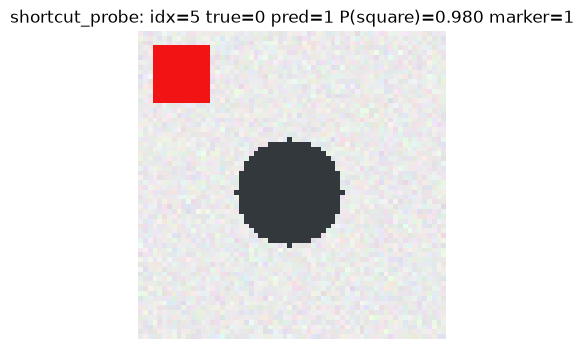

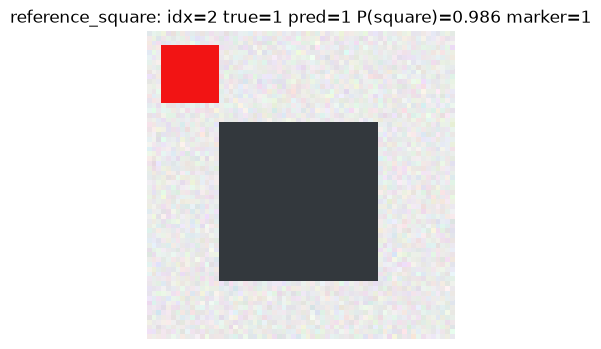

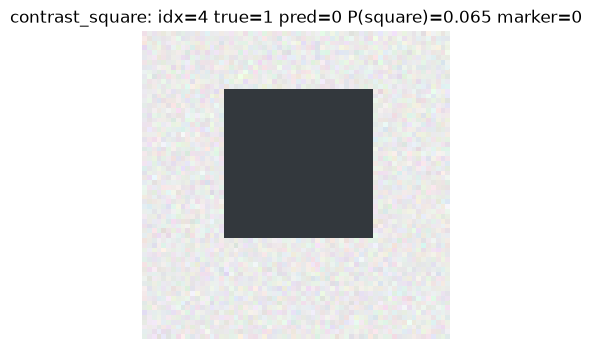

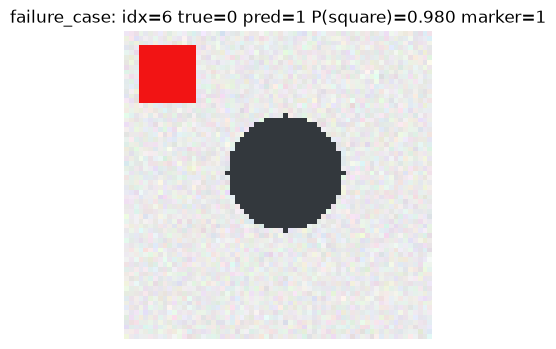

In [6]:
#@title View the assigned image cases
for name, idx in zip(assigned_image_cases["case_name"], assigned_image_cases["image_index"]):
    show_image_case(int(idx), title_prefix=f"{name}: ")

# Your Method Implementation

Use this section to install packages, import libraries, write helper functions, and adapt your assigned XAI method.

You may use external documentation. You may also decide that your method cannot reasonably be applied to an event, but you must explain why.

Suggested workflow:

1. Identify what inputs your method needs: tabular rows, images, gradients, model probabilities, labels, background data, perturbed samples, etc.
2. Decide whether your method is local, global, visual, counterfactual, or something else.
3. Implement the smallest version that can answer one event.
4. Reuse and adapt it across events.
5. Record both successes and failures honestly.


In [7]:
# Your implementation scratchpad.
# Add imports, installations, helper functions, and experiments here.

# Examples of things you might add in Colab, depending on your method:
# !pip install shap lime captum torchcam alibi PyALE
# import shap
# from lime.lime_tabular import LimeTabularExplainer

print("Event guide:")
display(event_guide)

# Keep your method-specific code here or add new cells below.


Event guide:


NameError: name 'event_guide' is not defined

## Individual Event Checklist

For each event, produce four things:

- **Output:** the plot, table, heatmap, counterfactual, ranking, or diagnostic your method produced.
- **Claim:** one sentence answering the event question, or saying the method cannot answer it.
- **Evidence quality:** why the output does or does not support the claim.
- **Medal:** Gold, Silver, Bronze, or DNF.

After each event, fill in the markdown Results Table near the top of the notebook. A DNF is not a failure of the student. It is evidence about the method's scope.


## Event 1: Find the Most Important Feature

**Question:** What variable most strongly influences the tabular model's predictions?

**Target:** Tabular risk model

**Your task:** Produce evidence that ranks or compares the influence of multiple features. If your method cannot produce global feature importance, explain the mismatch.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 1 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 2: Explain One Specific Prediction

**Question:** Why did this individual tabular prediction occur?

**Target:** Tabular local case

**Your task:** Use `tabular_local_case` and explain the model's prediction for that row. Your answer should refer to row-specific evidence.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [13]:
# Event 2: Counterfactual explanation for Model 1 (tabular risk model)
# A counterfactual is a nearby, plausible row for which the model changes its prediction.

def find_tabular_counterfactual(row_index):
    original = X_test.iloc[[row_index]][feature_names].copy()
    original_probability = float(predict_risk_proba(original)[0, 1])
    original_prediction = int(original_probability >= 0.5)
    train_values = X_train[feature_names]
    scale = train_values.std(ddof=0).replace(0, 1.0)

    candidates = []
    for feature in feature_names:
        values = np.unique(np.quantile(train_values[feature], np.linspace(0, 1, 31)))
        for value in values:
            candidate = original.copy()
            candidate.at[candidate.index[0], feature] = value
            probability = float(predict_risk_proba(candidate)[0, 1])
            if int(probability >= 0.5) != original_prediction:
                distance = abs(value - original.iloc[0][feature]) / scale[feature]
                candidates.append((distance, candidate, probability, feature))

    if candidates:
        _, counterfactual, counterfactual_probability, _ = min(candidates, key=lambda item: item[0])
    else:
        # Fall back to the nearest unlike training row if no one-feature flip exists.
        train_predictions = (predict_risk_proba(train_values)[:, 1] >= 0.5).astype(int)
        unlike = train_values.loc[train_predictions != original_prediction]
        if unlike.empty:
            raise ValueError("No opposite-prediction rows were found.")
        distances = (((unlike - original.iloc[0]) / scale) ** 2).sum(axis=1)
        counterfactual = unlike.loc[[distances.idxmin()]].copy()
        counterfactual_probability = float(predict_risk_proba(counterfactual)[0, 1])

    changes = pd.DataFrame({
        "feature": feature_names,
        "original": original.iloc[0].to_numpy(),
        "counterfactual": counterfactual.iloc[0].to_numpy(),
    })
    changes["changed"] = changes["original"] != changes["counterfactual"]
    changes["standardized_change"] = (
        (changes["counterfactual"] - changes["original"]) / scale.to_numpy()
    ).abs()

    return original, counterfactual, changes.sort_values(
        "standardized_change", ascending=False
    ), original_prediction, counterfactual_probability


cf_original_1, cf_tabular_1, cf_changes_1, cf_prediction_1, cf_probability_1 = (
    find_tabular_counterfactual(tabular_local_case)
)

print("Model 1 counterfactual explanation")
print(f"Test row index: {tabular_local_case}")
print(f"Original prediction: {cf_prediction_1} (P(high risk)={predict_risk_proba(cf_original_1)[0, 1]:.3f})")
print(f"Counterfactual prediction: {int(cf_probability_1 >= 0.5)} (P(high risk)={cf_probability_1:.3f})")
print("Changed features:")
display(cf_changes_1[cf_changes_1["changed"]].reset_index(drop=True))


Model 1 counterfactual explanation
Test row index: 718
Original prediction: 0 (P(high risk)=0.499)
Counterfactual prediction: 1 (P(high risk)=0.502)
Changed features:


,feature,original,counterfactual,changed,standardized_change
0,debt_ratio,0.281178,0.283247,True,0.013044


**Model 1: A counterfactual search found that changing only `debt_ratio` from 0.281 to 0.283 changed the prediction to high risk. This suggests that `debt_ratio` was decisive for this individual prediction, although the result is fragile because the probability changed only slightly and counterfactuals show model sensitivity, not causality.**

Model 2 counterfactual explanation
Original image index: 5; true label: 0


,counterfactual,P(square),predicted_label
0,original,0.980,1
1,marker removed,0.018,0
2,marker added,0.980,1
3,central shape swapped,0.985,1


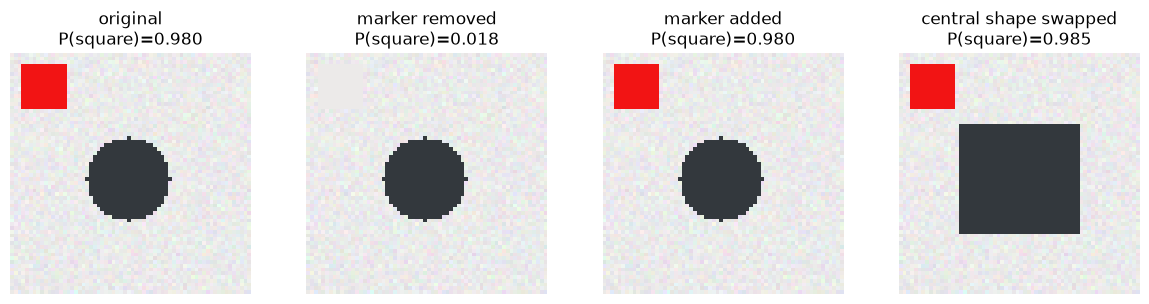

In [11]:
# Event 2: Counterfactual explanation for Model 2 (image shortcut model)
# Use structured edits so each counterfactual has a visual meaning.

def remove_corner_marker(image):
    edited = image.copy()
    background = np.median(edited[16:24, 3:15, :], axis=(0, 1))
    edited[3:15, 3:15, :] = background
    return edited


def add_corner_marker(image):
    edited = image.copy()
    edited[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08], dtype=np.float32)
    return edited


def swap_central_shape(image, donor):
    edited = image.copy()
    edited[16:48, 16:48, :] = donor[16:48, 16:48, :]
    return edited


def explain_image_counterfactual(image_index):
    original = test_imgs[image_index]
    donor_index = image_reference_case if image_index != image_reference_case else image_contrast_case
    candidates = {
        "original": original,
        "marker removed": remove_corner_marker(original),
        "marker added": add_corner_marker(original),
        "central shape swapped": swap_central_shape(original, test_imgs[donor_index]),
    }
    candidate_images = np.stack(list(candidates.values()))
    probabilities = predict_image_proba(candidate_images)[:, 1]
    results = pd.DataFrame({
        "counterfactual": list(candidates),
        "P(square)": np.round(probabilities, 3),
        "predicted_label": (probabilities >= 0.5).astype(int),
    })
    return candidates, results


cf_images_2, cf_results_2 = explain_image_counterfactual(image_shortcut_case)
print("Model 2 counterfactual explanation")
print(f"Original image index: {image_shortcut_case}; true label: {test_y[image_shortcut_case]}")
display(cf_results_2)

fig, axes = plt.subplots(1, len(cf_images_2), figsize=(12, 3))
for axis, (name, image), probability in zip(axes, cf_images_2.items(), cf_results_2["P(square)"]):
    axis.imshow(image)
    axis.set_title(f"{name}\nP(square)={probability:.3f}")
    axis.axis("off")
plt.tight_layout()
plt.show()


**Model 2: Removing the red corner marker flips the prediction from square to circle; changing the central shape alone does not.**

## Event 3: Detect Dataset Bias or a Shortcut

**Question:** Is the image model relying on a spurious shortcut?

**Target:** Image shortcut probe

**Your task:** Investigate whether the classifier uses the red corner marker, the shape, or both. Your method may need adaptation if it is not an image method.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 3 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 4: Understand a Feature's Global Effect

**Question:** As one tabular feature changes, what happens to predictions?

**Target:** Tabular risk model

**Your task:** Choose a feature such as `debt_ratio`, `income_k`, or `age`. Show how predictions change as that feature changes, or explain why your method cannot answer a global effect question.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Event 4: global model effect of debt_ratio


,debt_ratio,mean_P_high_risk,high_risk_prediction_rate
0,0.075437,0.148250,0.008000
1,0.112213,0.148731,0.008000
2,0.148988,0.148561,0.008000
3,0.185764,0.148381,0.008000
4,0.222540,0.154925,0.008000
5,0.259315,0.168970,0.012000
6,0.296091,0.212830,0.017333
7,0.332866,0.217384,0.017333
8,0.369642,0.232004,0.018667
9,0.406418,0.261230,0.030667


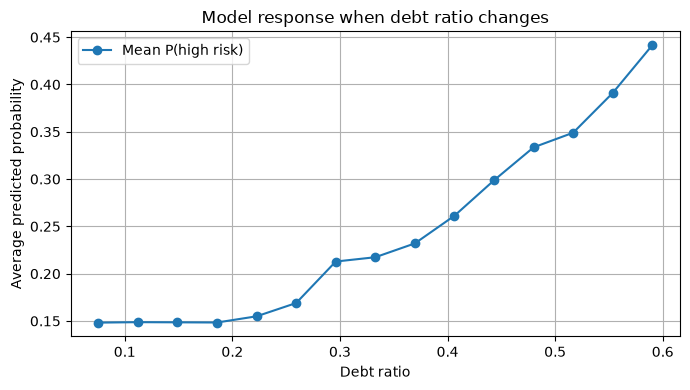

In [24]:
# Event 4: Global counterfactual effect of debt_ratio
# Sweep one feature across the test set while preserving each row's other features.

feature_to_sweep_4 = "debt_ratio"
sweep_values_4 = np.linspace(
    float(X_train[feature_to_sweep_4].quantile(0.05)),
    float(X_train[feature_to_sweep_4].quantile(0.95)),
    15,
)

global_effect_4 = []
for value in sweep_values_4:
    intervened_test_4 = X_test[feature_names].copy()
    intervened_test_4[feature_to_sweep_4] = value
    probabilities_4 = predict_risk_proba(intervened_test_4)[:, 1]
    global_effect_4.append({
        feature_to_sweep_4: value,
        "mean_P_high_risk": probabilities_4.mean(),
        "high_risk_prediction_rate": (probabilities_4 >= 0.5).mean(),
    })

global_effect_4 = pd.DataFrame(global_effect_4)
print(f"Event 4: global model effect of {feature_to_sweep_4}")
display(global_effect_4)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    global_effect_4[feature_to_sweep_4],
    global_effect_4["mean_P_high_risk"],
    marker="o",
    label="Mean P(high risk)",
)
ax.set_xlabel("Debt ratio")
ax.set_ylabel("Average predicted probability")
ax.set_title("Model response when debt ratio changes")
ax.legend()
plt.tight_layout()
plt.show()


**Event 4 interpretation:** Increasing `debt_ratio` from 0.075 to 0.590 increased the average predicted probability of high risk from 0.148 to 0.442. The share of rows predicted high risk also increased from 0.8% to 25.2%. This supports a positive global model effect: higher debt ratios generally produce higher predicted risk. Because the sweep changes only `debt_ratio` while holding correlated features fixed, it describes model behavior rather than a causal effect.

## Event 5: Compare Two Predictions

**Question:** Why were two cases classified differently?

**Target:** Tabular or image comparison cases

**Your task:** Compare `tabular_low_case` vs. `tabular_high_case`, or compare two assigned image cases. Explain the difference, not just each case separately.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [17]:
# Event 5: Compare two tabular predictions with counterfactual interventions
# Compare the low-risk and high-risk cases, then test each high-case feature in isolation.

def compare_tabular_predictions(low_index, high_index):
    low_case = X_test.iloc[[low_index]][feature_names].copy()
    high_case = X_test.iloc[[high_index]][feature_names].copy()
    low_probability = float(predict_risk_proba(low_case)[0, 1])
    high_probability = float(predict_risk_proba(high_case)[0, 1])
    scale = X_train[feature_names].std(ddof=0).replace(0, 1.0)

    differences = pd.DataFrame({
        "feature": feature_names,
        "low_case_value": low_case.iloc[0].to_numpy(),
        "high_case_value": high_case.iloc[0].to_numpy(),
    })
    differences["raw_difference"] = (
        differences["high_case_value"] - differences["low_case_value"]
    )
    differences["standardized_difference"] = (
        differences["raw_difference"] / scale.to_numpy()
    ).abs()

    interventions = []
    for feature in feature_names:
        intervened = low_case.copy()
        intervened.at[intervened.index[0], feature] = high_case.iloc[0][feature]
        intervention_probability = float(predict_risk_proba(intervened)[0, 1])
        interventions.append({
            "feature_changed": feature,
            "low_case_P_high_risk": low_probability,
            "after_replacing_with_high_case_value": intervention_probability,
            "probability_change": intervention_probability - low_probability,
        })

    interventions = pd.DataFrame(interventions)
    interventions["absolute_probability_change"] = interventions["probability_change"].abs()
    return low_case, high_case, low_probability, high_probability, differences, interventions


(
    cf_low_case_5,
    cf_high_case_5,
    cf_low_probability_5,
    cf_high_probability_5,
    comparison_5,
    interventions_5,
) = compare_tabular_predictions(tabular_low_case, tabular_high_case)

print("Event 5: comparing tabular low-risk and high-risk cases")
print(f"Low-risk case {tabular_low_case}: P(high risk)={cf_low_probability_5:.3f}")
print(f"High-risk case {tabular_high_case}: P(high risk)={cf_high_probability_5:.3f}")

case_profile_5 = pd.DataFrame({
    "feature": feature_names,
    "low-risk case": cf_low_case_5.iloc[0].to_numpy(),
    "high-risk case": cf_high_case_5.iloc[0].to_numpy(),
})
print("Feature values for both cases:")
display(case_profile_5)

print("Largest row differences:")
display(comparison_5.sort_values("standardized_difference", ascending=False).reset_index(drop=True))
print("Largest one-feature intervention effects:")
display(
    interventions_5.sort_values("absolute_probability_change", ascending=False)
    .reset_index(drop=True)
)


Event 5: comparing tabular low-risk and high-risk cases
Low-risk case 565: P(high risk)=0.022
High-risk case 564: P(high risk)=0.789
Feature values for both cases:


,feature,low-risk case,high-risk case
0,age,54.000000,28.000000
1,income_k,102.549186,38.814284
2,debt_ratio,0.044438,0.535676
3,loyalty_years,21.356207,1.484895
4,recent_late_payments,0.000000,6.000000
5,savings_k,18.422915,3.738429
6,app_minutes,23.505863,23.557222
7,support_tickets,0.000000,1.000000
8,zip_proxy,0.000000,1.000000
9,promo_seen,0.000000,1.000000


Largest row differences:


,feature,low_case_value,high_case_value,raw_difference,standardized_difference
0,recent_late_payments,0.000000,6.000000,6.000000,5.266311
1,loyalty_years,21.356207,1.484895,-19.871312,3.331773
2,debt_ratio,0.044438,0.535676,0.491237,3.097938
3,income_k,102.549186,38.814284,-63.734903,2.652263
4,zip_proxy,0.000000,1.000000,1.000000,2.383548
5,promo_seen,0.000000,1.000000,1.000000,2.009454
6,support_tickets,0.000000,1.000000,1.000000,1.543115
7,age,54.000000,28.000000,-26.000000,1.537369
8,savings_k,18.422915,3.738429,-14.684486,1.090246
9,app_minutes,23.505863,23.557222,0.051359,0.007328


Largest one-feature intervention effects:


,feature_changed,low_case_P_high_risk,after_replacing_with_high_case_value,probability_change,absolute_probability_change
0,debt_ratio,0.022119,0.168722,0.146603,0.146603
1,recent_late_payments,0.022119,0.125176,0.103057,0.103057
2,zip_proxy,0.022119,0.089047,0.066928,0.066928
3,income_k,0.022119,0.079345,0.057226,0.057226
4,savings_k,0.022119,0.042186,0.020067,0.020067
5,loyalty_years,0.022119,0.038606,0.016487,0.016487
6,age,0.022119,0.033175,0.011056,0.011056
7,support_tickets,0.022119,0.028689,0.006570,0.006570
8,promo_seen,0.022119,0.028686,0.006567,0.006567
9,app_minutes,0.022119,0.022119,0.000000,0.000000


**Event 5 interpretation:** The high-risk case has `P(high risk)=0.789`, compared with `0.022` for the low-risk case. The cases differ most in recent late payments, loyalty years, debt ratio, and income. When each high-case value is inserted into the low-risk row separately, `debt_ratio` produces the largest probability increase (`+0.147`), followed by `recent_late_payments` (`+0.103`). Together, these feature differences explain why the model separates the two cases, although the one-feature interventions do not measure interactions or prove causality.

## Event 6: Detect Feature Interactions

**Question:** Which tabular variables work together?

**Target:** Tabular risk model

**Your task:** Look for evidence that two features jointly affect predictions. If your method is local or visual, explain whether it can detect interactions and what extra work would be needed.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 6 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 7: Find Where the Model Is Looking

**Question:** What region of an image drives the prediction?

**Target:** Image model

**Your task:** Use one or more assigned image cases. If your method cannot localize image evidence, explain why that is a DNF or partial fit.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 7 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 8: Explain a Failure

**Question:** Why did the model make this mistake?

**Target:** Tabular and/or image failure case

**Your task:** Use `tabular_failure_case` or `image_failure_case`. Explain the likely reason for the incorrect prediction using your method, or explain why it cannot diagnose a single failure.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [22]:
# Event 8: Explain the tabular failure case with a counterfactual
# The selected failure is a false negative: the true label is high risk, but the model predicts low risk.

failure_original_8, failure_counterfactual_8, failure_changes_8, failure_prediction_8, failure_cf_probability_8 = (
    find_tabular_counterfactual(tabular_failure_case)
)
failure_true_label_8 = int(y_test.iloc[tabular_failure_case])
failure_probability_8 = float(predict_risk_proba(failure_original_8)[0, 1])

failure_profile_8 = pd.DataFrame({
    "feature": feature_names,
    "failure_case": failure_original_8.iloc[0].to_numpy(),
    "counterfactual_value": failure_counterfactual_8.iloc[0].to_numpy(),
})
failure_profile_8["changed"] = (
    failure_profile_8["failure_case"] != failure_profile_8["counterfactual_value"]
)

print("Event 8: counterfactual explanation of a tabular failure")
print(f"Test row index: {tabular_failure_case}")
print(f"True label: {failure_true_label_8} (high risk)")
print(f"Model prediction: {failure_prediction_8} (low risk; P(high risk)={failure_probability_8:.3f})")
print("Failure-case feature values and counterfactual values:")
display(failure_profile_8)
print("Features changed in the nearest prediction-flipping counterfactual:")
display(failure_changes_8[failure_changes_8["changed"]].reset_index(drop=True))

# Event 8: Explain the tabular failure case with a counterfactual
# False Negative: True label = 1 (High Risk), Model prediction = 0 (Low Risk)

failure_original_8, failure_counterfactual_8, failure_changes_8, failure_prediction_8, failure_cf_probability_8 = (
    find_tabular_counterfactual(tabular_failure_case)
)

failure_true_label_8 = int(y_test.iloc[tabular_failure_case])
failure_probability_8 = float(predict_risk_proba(failure_original_8)[0, 1])

# Combine profile and changes into a single diagnostic table
failure_summary_8 = failure_changes_8[failure_changes_8["changed"]].copy()
failure_summary_8["direction"] = np.where(
    failure_summary_8["counterfactual"] > failure_summary_8["original"],
    "Increase",
    "Decrease"
)

print("=" * 60)
print("Event 8: Counterfactual Explanation of a Model Failure")
print("=" * 60)
print(f"Test Row Index   : {tabular_failure_case}")
print(f"True Label       : {failure_true_label_8} (High Risk)")
print(f"Model Prediction : {failure_prediction_8} (Low Risk)")
print(f"Baseline P(Risk) : {failure_probability_8:.3f}")
print(f"Flipped P(Risk)  : {failure_cf_probability_8:.3f}")
print(f"Distance to 0.500: {0.5 - failure_probability_8:.3f} probability points")
print("-" * 60)

Event 8: counterfactual explanation of a tabular failure
Test row index: 1
True label: 1 (high risk)
Model prediction: 0 (low risk; P(high risk)=0.400)
Failure-case feature values and counterfactual values:


,feature,failure_case,counterfactual_value,changed
0,age,31.000000,31.000000,False
1,income_k,66.076229,66.076229,False
2,debt_ratio,0.723571,0.723571,False
3,loyalty_years,2.792308,2.792308,False
4,recent_late_payments,1.000000,2.000000,True
5,savings_k,5.975494,5.975494,False
6,app_minutes,16.112855,16.112855,False
7,support_tickets,0.000000,0.000000,False
8,zip_proxy,0.000000,0.000000,False
9,promo_seen,1.000000,1.000000,False


Features changed in the nearest prediction-flipping counterfactual:


,feature,original,counterfactual,changed,standardized_change
0,recent_late_payments,1.0,2.0,True,0.877718


Event 8: Counterfactual Explanation of a Model Failure
Test Row Index   : 1
True Label       : 1 (High Risk)
Model Prediction : 0 (Low Risk)
Baseline P(Risk) : 0.400
Flipped P(Risk)  : 0.524
Distance to 0.500: 0.100 probability points
------------------------------------------------------------


**Event 8 interpretation:** Row 1 is a false negative: the true label is high risk, but the model predicts low risk with `P(high risk)=0.400`. A nearest counterfactual changes only `recent_late_payments` from 1 to 2, which flips the prediction to high risk. This suggests the model underweighted or thresholded this case incorrectly despite its high `debt_ratio` of 0.724. The counterfactual identifies model sensitivity, not the true cause of the applicant's risk.

## Event 9: Estimate Trustworthiness

**Question:** Should a human trust this prediction?

**Target:** Either target model

**Your task:** Use your method to argue for or against trusting one prediction. Be specific about what your method can and cannot establish.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 9 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 10: Reverse Engineer the Model

**Question:** What strategy has each model learned?

**Target:** Both target models

**Your task:** Synthesize evidence across events. A single output is usually not enough; explain what your method revealed and what remains unknown.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [ ]:
# Event 10 workspace: implement or adapt YOUR assigned method here.
# Add as many cells as you need. This placeholder is intentionally not an explanation.

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


# Final Model Profile

After all ten events, write a short synthesis.

**Tabular model strategy:**  
Which features seem important? Did you find global effects, local effects, interactions, or suspicious proxies? What can your method support?

**Image model strategy:**  
Does the classifier appear to use the shape, the red marker, or both? What evidence supports that claim?

**Your method's decathlon profile:**  
Where did your method perform well? Where did it fail? What kind of explanation question is it best suited for?

**Open questions:**  
What would you want to compare with classmates who used other methods?
